In [1]:
# -------------------------------------
# Library configuration
# -------------------------------------

# EDA methodology adapted from
# https://www.analyticsvidhya.com/blog/2022/07/step-by-step-exploratory-data-analysis-eda-using-python/

# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#to ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Lucky number
random_state = 8

In [3]:
# Loading dataset
dataset = pd.read_csv('data/cs199_data.csv')

dataset.head()

,SAMPLEID,6_ANSWERDATE,6_SEX,6_AGE,6_AGEID,6_PREFECTURE,6_AREA,6_MARRIED,6_CHILD,6_HINCOME,...,6_Mental_group,6_Covid_group,6_K6_group3,6_K6_group2,6_PHQ9_%,6_GAD_%,6_PHQ9_item9,6_PHQ9_SI,6_LSNS_group,6_AUDIT_group
0,1106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1916,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3793,5-13-2024,1.0,57.0,10.0,40.0,8.0,2.0,2.0,4.0,...,4.0,4.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,0.0


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24050 entries, 0 to 24049
Columns: 114 entries, SAMPLEID to 6_AUDIT_group
dtypes: float64(109), int64(1), object(4)
memory usage: 20.9+ MB


In [5]:
dataset.nunique()

SAMPLEID         24050
6_ANSWERDATE         8
6_SEX                2
6_AGE               69
6_AGEID              9
                 ...  
6_GAD_%              2
6_PHQ9_item9         4
6_PHQ9_SI            2
6_LSNS_group         2
6_AUDIT_group        3
Length: 114, dtype: int64

In [6]:
dataset.isnull().sum()

SAMPLEID             0
6_ANSWERDATE     21391
6_SEX            21391
6_AGE            21391
6_AGEID          21391
                 ...  
6_GAD_%          21391
6_PHQ9_item9     21391
6_PHQ9_SI        21391
6_LSNS_group     21391
6_AUDIT_group    21391
Length: 114, dtype: int64

In [7]:
dataset.isnull().sum()

SAMPLEID             0
6_ANSWERDATE     21391
6_SEX            21391
6_AGE            21391
6_AGEID          21391
                 ...  
6_GAD_%          21391
6_PHQ9_item9     21391
6_PHQ9_SI        21391
6_LSNS_group     21391
6_AUDIT_group    21391
Length: 114, dtype: int64

In [8]:
# Check for duplicates on each row.
dataset.duplicated().value_counts()

False    24050
Name: count, dtype: int64

In [9]:
# Code snippet to help us see the percentage of missing values per column
(dataset.isnull().sum()/(len(dataset)))*100

SAMPLEID          0.000000
6_ANSWERDATE     88.943867
6_SEX            88.943867
6_AGE            88.943867
6_AGEID          88.943867
                   ...    
6_GAD_%          88.943867
6_PHQ9_item9     88.943867
6_PHQ9_SI        88.943867
6_LSNS_group     88.943867
6_AUDIT_group    88.943867
Length: 114, dtype: float64

In [10]:
columns  = dataset.columns

for column in columns:
    print(column)

SAMPLEID
6_ANSWERDATE
6_SEX
6_AGE
6_AGEID
6_PREFECTURE
6_AREA
6_MARRIED
6_CHILD
6_HINCOME
6_PINCOME
6_JOB
6_STUDENT
6_Number_fam
6_SchoolGrade
6_YearsEnrolled
6_VacNum
6_Med_self
6_Medself_covid
6_Med_fam
6_Medfam_covid
6_Current_physical
6_Past_physical
6_Current_mental
6_Past_mental
6_Current_covid19
6_Past_covid19
6_Exercise
6_HealthyDiet
6_FavoriteActivity
6_Interaction_offline
6_Interaction_online
6_PB_Continuous
6_PB_Altruistic
6_PB_Avoidant
6_Trust_gov
6_Trust_SM
6_Vaccination_will
6_PB_understanding
6_Optimism
6_HealthySleep
6_DeteriorationEconomy
6_DeteriorationInteract
6_Frustration
6_CovidAnxiety
6_CovidSleepless
6_DifficultyLiving
6_DifficultyWork
6_PTG1_S22
6_PTG2_S23
6_PTG3_S24
6_PTG4_S25
6_PTG5_S_26
6_PTG6_S27
6_Social_Capital_Q8S1
6_Social_Capital_Q8S2
6_Social_Capital_Q8S3
6_Social_Capital_Q8S4
6_Social_Capital_Q8S5
6_Social_Capital_Q9S1
6_Social_Capital_Q9S2
6_Social_Capital_Q9S3
6_Social_Capital_Q10S1_1
6_Social_Capital_Q10S1_2
6_Social_Capital_Q10S1_3
6_Social_Capit

In [11]:
# Sorting dataset based on SAMPLEID
dataset_sorted = dataset.sort_values(by=['SAMPLEID'])

In [12]:
initial_rows = len(dataset_sorted)
dataset_cleaned = dataset_sorted.dropna().dropna(subset=['6_PINCOME', '6_HINCOME'])
final_rows = len(dataset_cleaned)
print(f"Number of rows dropped: {initial_rows - final_rows}")

Number of rows dropped: 21391


In [13]:
# Gathering columns
column_names = dataset_cleaned.columns.tolist()

# Displaying column names
column_names

['SAMPLEID',
 '6_ANSWERDATE',
 '6_SEX',
 '6_AGE',
 '6_AGEID',
 '6_PREFECTURE',
 '6_AREA',
 '6_MARRIED',
 '6_CHILD',
 '6_HINCOME',
 '6_PINCOME',
 '6_JOB',
 '6_STUDENT',
 '6_Number_fam',
 '6_SchoolGrade',
 '6_YearsEnrolled',
 '6_VacNum',
 '6_Med_self',
 '6_Medself_covid',
 '6_Med_fam',
 '6_Medfam_covid',
 '6_Current_physical',
 '6_Past_physical',
 '6_Current_mental',
 '6_Past_mental',
 '6_Current_covid19',
 '6_Past_covid19',
 '6_Exercise',
 '6_HealthyDiet',
 '6_FavoriteActivity',
 '6_Interaction_offline',
 '6_Interaction_online',
 '6_PB_Continuous',
 '6_PB_Altruistic',
 '6_PB_Avoidant',
 '6_Trust_gov',
 '6_Trust_SM',
 '6_Vaccination_will',
 '6_PB_understanding',
 '6_Optimism',
 '6_HealthySleep',
 '6_DeteriorationEconomy',
 '6_DeteriorationInteract',
 '6_Frustration',
 '6_CovidAnxiety',
 '6_CovidSleepless',
 '6_DifficultyLiving',
 '6_DifficultyWork',
 '6_PTG1_S22',
 '6_PTG2_S23',
 '6_PTG3_S24',
 '6_PTG4_S25',
 '6_PTG5_S_26',
 '6_PTG6_S27',
 '6_Social_Capital_Q8S1',
 '6_Social_Capital_Q8S2

In [14]:
df_wilcoxon = pd.read_csv('data/dataset_differences.csv')
df_wilcoxon.head()

,SAMPLEID,K6_total_old,PHQ9_total_old,GAD7_total_old,SSS8_total_old,PTGI-X(Q7_22_27)_old,SHS_total_old,UCLA_total_old,LSNS6_total_old,AUDIT_old,...,AUDIT_new,K6_total_diff,PHQ9_total_diff,GAD7_total_diff,SSS8_total_diff,PTGI-X(Q7_22_27)_diff,SHS_total_diff,UCLA_total_diff,LSNS6_total_diff,AUDIT_diff
0,3793,4.0,5.0,4.0,13.0,0.0,1.50,40.0,4.0,4.0,...,6,8.0,10.0,10.0,5.0,19.0,2.50,-16.0,0.0,2.0
1,9703,0.0,0.0,0.0,1.0,7.0,4.00,10.0,17.0,0.0,...,0,1.0,0.0,0.0,0.0,-4.0,0.50,1.0,1.0,0.0
2,11532,24.0,0.0,0.0,4.0,0.0,4.50,31.0,4.0,0.0,...,0,-23.0,2.0,0.0,-3.0,0.0,-0.50,1.0,-4.0,0.0
3,15778,0.0,0.0,0.0,0.0,13.0,5.25,16.0,15.0,0.0,...,0,0.0,0.0,0.0,0.0,5.0,0.25,5.0,-2.0,0.0
4,18713,0.0,0.0,0.0,0.0,18.0,5.00,23.0,5.0,0.0,...,0,0.0,2.0,0.0,0.0,-3.0,0.25,-1.0,13.0,0.0


In [15]:
#  ucla
X = np.array(df_wilcoxon.UCLA_total_old)
Y = np.array(df_wilcoxon.UCLA_total_new)
res = stats.wilcoxon(X, Y, alternative='two-sided')
res

WilcoxonResult(statistic=1105938.0, pvalue=4.030348402741578e-08)

In [16]:
#  ucla
X = np.array(df_wilcoxon.UCLA_total_old)
Y = np.array(df_wilcoxon.UCLA_total_new)
res = stats.wilcoxon(X, Y, alternative='greater')
res

WilcoxonResult(statistic=1444473.0, pvalue=2.015174201370789e-08)

In [17]:
#  ucla
X = np.array(df_wilcoxon.UCLA_total_old)
Y = np.array(df_wilcoxon.UCLA_total_new)
res = stats.wilcoxon(X, Y, alternative='less')
res

WilcoxonResult(statistic=1444473.0, pvalue=0.999999979848258)

In [18]:
# Setting attributes
# Dropping Prefecture, Student, and PTG subscales
# as per Nunez 2022

# removed targets as well from attributes

# Setting attributes
dataset_cleaned = dataset_cleaned[[
 '6_SEX', # 1 Male, 2 Femail
 '6_AGE',
 '6_MARRIED', # 1 unmarried, 2 married
 '6_JOB', # 1 civil servant, 2 management and officers, 3 company employee (clerical), 4 company employee (technical, 5 (company empolyee (other), 6 self-employed, 7 freelance, 8 full-time housewife (househusband), 9 part-time workers, 10 students, 11 others, 12 unemployed
 '6_HINCOME_group', # 1 < 200 million yen, 2 200-390 million yen, 3 400-590million yen, 4 600-790 million yen, 5 > 800 million yen, 6 unknown


 '6_Exercise', # i tried to exercise for my health (both indoors and outdoors) - 1 notapplicable - 7 very applicable
 '6_HealthyDiet', # i ate with a nutritional balance in mind - 1 not applicable - 7 very applicable
 '6_HealthySleep', #
 '6_Interaction_offline',
 '6_Interaction_online',
 '6_DeteriorationEconomy', # economic situation worsened
 '6_DeteriorationInteract', # interpersonal relationships with close people such as family and friends deteroirated
 '6_Frustration',
 '6_CovidAnxiety',
 '6_CovidSleepless',
 '6_DifficultyLiving',
 '6_DifficultyWork',


 '6_K6_total', #ok
 '6_PHQ9_total', #ok
 '6_SSS8_total', #ok
 '6_UCLA_total', #ok
 '6_LSNS6_total' ]] #ok

In [19]:
dataset_cleaned.nunique()

6_SEX                       2
6_AGE                      69
6_MARRIED                   2
6_JOB                      12
6_HINCOME_group             6
6_Exercise                  7
6_HealthyDiet               7
6_HealthySleep              7
6_Interaction_offline       7
6_Interaction_online        7
6_DeteriorationEconomy      7
6_DeteriorationInteract     7
6_Frustration               7
6_CovidAnxiety              7
6_CovidSleepless            7
6_DifficultyLiving          7
6_DifficultyWork            7
6_K6_total                 25
6_PHQ9_total               28
6_SSS8_total               32
6_UCLA_total               31
6_LSNS6_total              31
dtype: int64

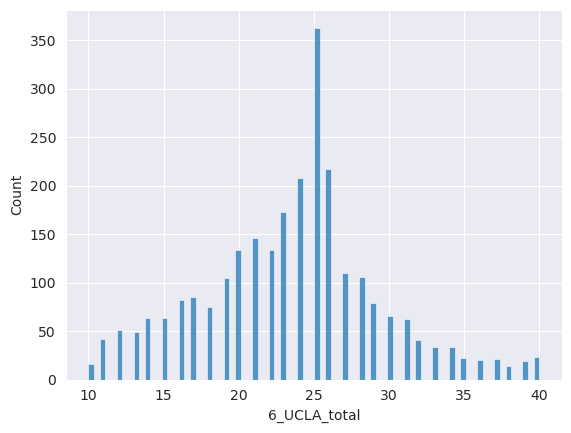

In [27]:
sns.histplot(dataset_cleaned['6_UCLA_total'], bins=80)
plt.show()

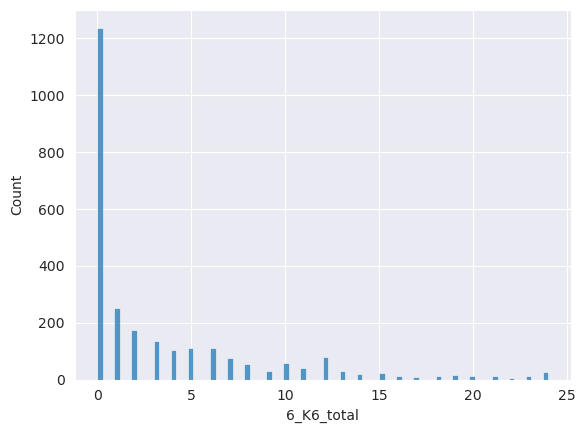

In [20]:
sns.histplot(dataset_cleaned['6_K6_total'], bins=80)
plt.show()

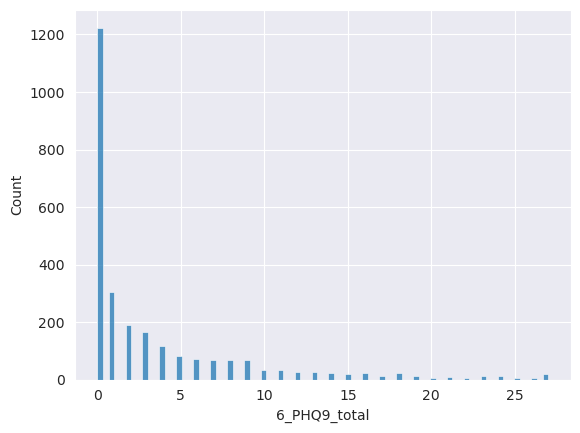

In [21]:
sns.histplot(dataset_cleaned['6_PHQ9_total'], bins=80)
plt.show()

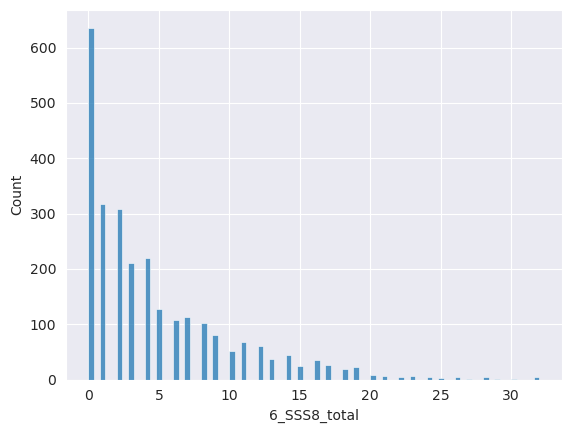

In [22]:
sns.histplot(dataset_cleaned['6_SSS8_total'], bins=80)
plt.show()

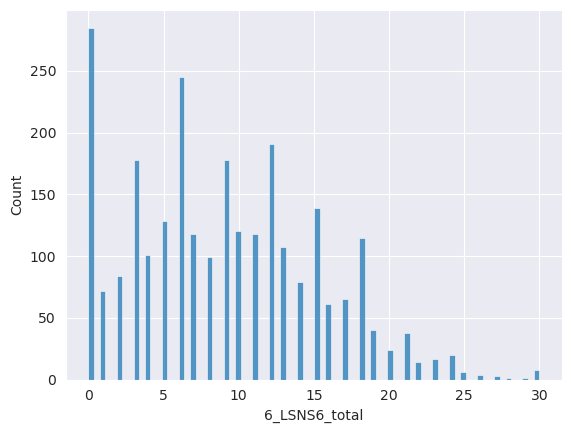

In [23]:
sns.histplot(dataset_cleaned['6_LSNS6_total'], bins=80)
plt.show()

In [28]:
dataset_cleaned['6_UCLA_total'].describe()

count    2659.000000
mean       23.464460
std         5.988307
min        10.000000
25%        20.000000
50%        24.000000
75%        26.000000
max        40.000000
Name: 6_UCLA_total, dtype: float64

In [29]:
## K6 Dataset
# Declaring function for K6
def k6_condition(x):
    if 0 <= x <= 12:
        return 'Unlikely distress'
    elif 13 <= x <= 24:
        return 'Likely distress'

## PHQ9 Dataset
# Declaring function for PHQ-9
def phq9_condition(x):
    if 0 <= x <= 4:
        return 'Minimal depression'
    elif 5 <= x <= 9:
        return 'Mild'
    elif 10 <= x <= 14:
        return 'Moderate'
    elif 15 <= x <= 19:
        return 'Moderately severe'
    elif 20 <= x <= 27:
        return 'Severe'

## SSS8 Dataset
# Declaring function for SSS-8
def sss8_condition(x):
    if 0 <= x <= 3:
        return 'Minimal'
    elif 4 <= x <= 7:
        return 'Low'
    elif 8 <= x <= 11:
        return 'Medium'
    elif 12 <= x <= 15:
        return 'High'
    elif 16 <= x <= 32:
        return 'Very high'

## UCLA Dataset
# Declaring function for UCLA Loneliness Scale (UCLA LS)
def ucla_ls_condition(x):
    if 0 <= x <= 19:
        return 'Minimal loneliness'
    elif 20 <= x <= 34:
        return 'Low'
    elif 35 <= x <= 49:
        return 'Moderate'
    elif 50 <= x <= 64:
        return 'Moderately high'
    elif 65 <= x <= 80:
        return 'High'

## LSNS6 Dataset
# Declaring function for LSNS-6
def lsns6_condition(x):
    if x == 0:
        return 'Minimal social engagement'
    elif x == 60:
        return 'High social engagement'
    else:
        return 'Intermediate social engagement'


In [30]:
# Applying functions to transform column values
dataset_cleaned['6_K6_total'] = dataset_cleaned['6_K6_total'].apply(k6_condition)
dataset_cleaned['6_PHQ9_total'] = dataset_cleaned['6_PHQ9_total'].apply(phq9_condition)
dataset_cleaned['6_SSS8_total'] = dataset_cleaned['6_SSS8_total'].apply(sss8_condition)
dataset_cleaned['6_UCLA_total'] = dataset_cleaned['6_UCLA_total'].apply(ucla_ls_condition)
dataset_cleaned['6_LSNS6_total'] = dataset_cleaned['6_LSNS6_total'].apply(lsns6_condition)


In [31]:
dataset_cleaned.head(10)

,6_SEX,6_AGE,6_MARRIED,6_JOB,6_HINCOME,6_Exercise,6_HealthyDiet,6_HealthySleep,6_Interaction_offline,6_Interaction_online,...,6_Frustration,6_CovidAnxiety,6_CovidSleepless,6_DifficultyLiving,6_DifficultyWork,6_K6_total,6_PHQ9_total,6_SSS8_total,6_UCLA_total,6_LSNS6_total
4,1.0,57.0,2.0,4.0,4.0,5.0,4.0,4.0,4.0,4.0,...,3.0,5.0,5.0,5.0,5.0,1,4,5,2,3
8,2.0,70.0,2.0,8.0,7.0,1.0,6.0,7.0,4.0,5.0,...,1.0,5.0,1.0,1.0,6.0,1,1,1,1,3
11,1.0,52.0,1.0,3.0,3.0,2.0,3.0,5.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1,1,1,2,1
15,1.0,66.0,2.0,3.0,4.0,6.0,5.0,5.0,5.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1,1,1,2,3
19,1.0,63.0,2.0,2.0,7.0,1.0,2.0,5.0,5.0,3.0,...,4.0,4.0,2.0,4.0,4.0,1,1,1,2,3
21,1.0,62.0,1.0,4.0,3.0,1.0,4.0,6.0,1.0,1.0,...,4.0,4.0,4.0,4.0,4.0,1,1,2,2,3
22,1.0,69.0,2.0,9.0,3.0,7.0,6.0,7.0,6.0,1.0,...,2.0,2.0,2.0,2.0,2.0,1,1,2,2,3
24,1.0,53.0,1.0,7.0,10.0,1.0,4.0,5.0,2.0,1.0,...,4.0,4.0,1.0,1.0,4.0,1,2,3,2,3
27,1.0,46.0,1.0,11.0,4.0,2.0,4.0,7.0,7.0,1.0,...,5.0,4.0,4.0,4.0,4.0,1,1,3,2,3
31,1.0,55.0,1.0,3.0,4.0,5.0,5.0,3.0,5.0,4.0,...,4.0,6.0,2.0,4.0,3.0,1,1,3,2,3


In [32]:
len(dataset_cleaned)

2659

In [33]:
# Descriptive statistics
dataset_cleaned.describe()

,6_SEX,6_AGE,6_MARRIED,6_JOB,6_HINCOME,6_Exercise,6_HealthyDiet,6_HealthySleep,6_Interaction_offline,6_Interaction_online,...,6_Frustration,6_CovidAnxiety,6_CovidSleepless,6_DifficultyLiving,6_DifficultyWork,6_K6_total,6_PHQ9_total,6_SSS8_total,6_UCLA_total,6_LSNS6_total
count,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000,...,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000
mean,1.417074,56.038736,1.644603,6.670177,3.932681,3.820985,4.195562,4.607371,4.164724,2.810831,...,2.808199,2.633697,2.144415,2.189921,2.314404,1.071455,1.450169,1.857841,1.806694,2.785634
std,0.493168,12.700980,0.478723,3.293959,2.754909,1.969939,1.675332,1.705135,1.829843,1.805835,...,1.614478,1.538229,1.380634,1.426015,1.513317,0.257633,0.939507,1.189094,0.495518,0.618808
min,1.000000,22.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,48.000000,1.000000,4.000000,2.000000,2.000000,3.000000,4.000000,3.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000
50%,1.000000,56.000000,2.000000,6.000000,3.000000,4.000000,4.000000,5.000000,4.000000,3.000000,...,3.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,3.000000
75%,2.000000,65.000000,2.000000,9.000000,5.000000,5.000000,5.000000,6.000000,5.000000,4.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,1.000000,1.000000,2.000000,2.000000,3.000000
max,2.000000,92.000000,2.000000,12.000000,10.000000,7.000000,7.000000,7.000000,7.000000,7.000000,...,7.000000,7.000000,7.000000,7.000000,7.000000,2.000000,5.000000,5.000000,3.000000,3.000000


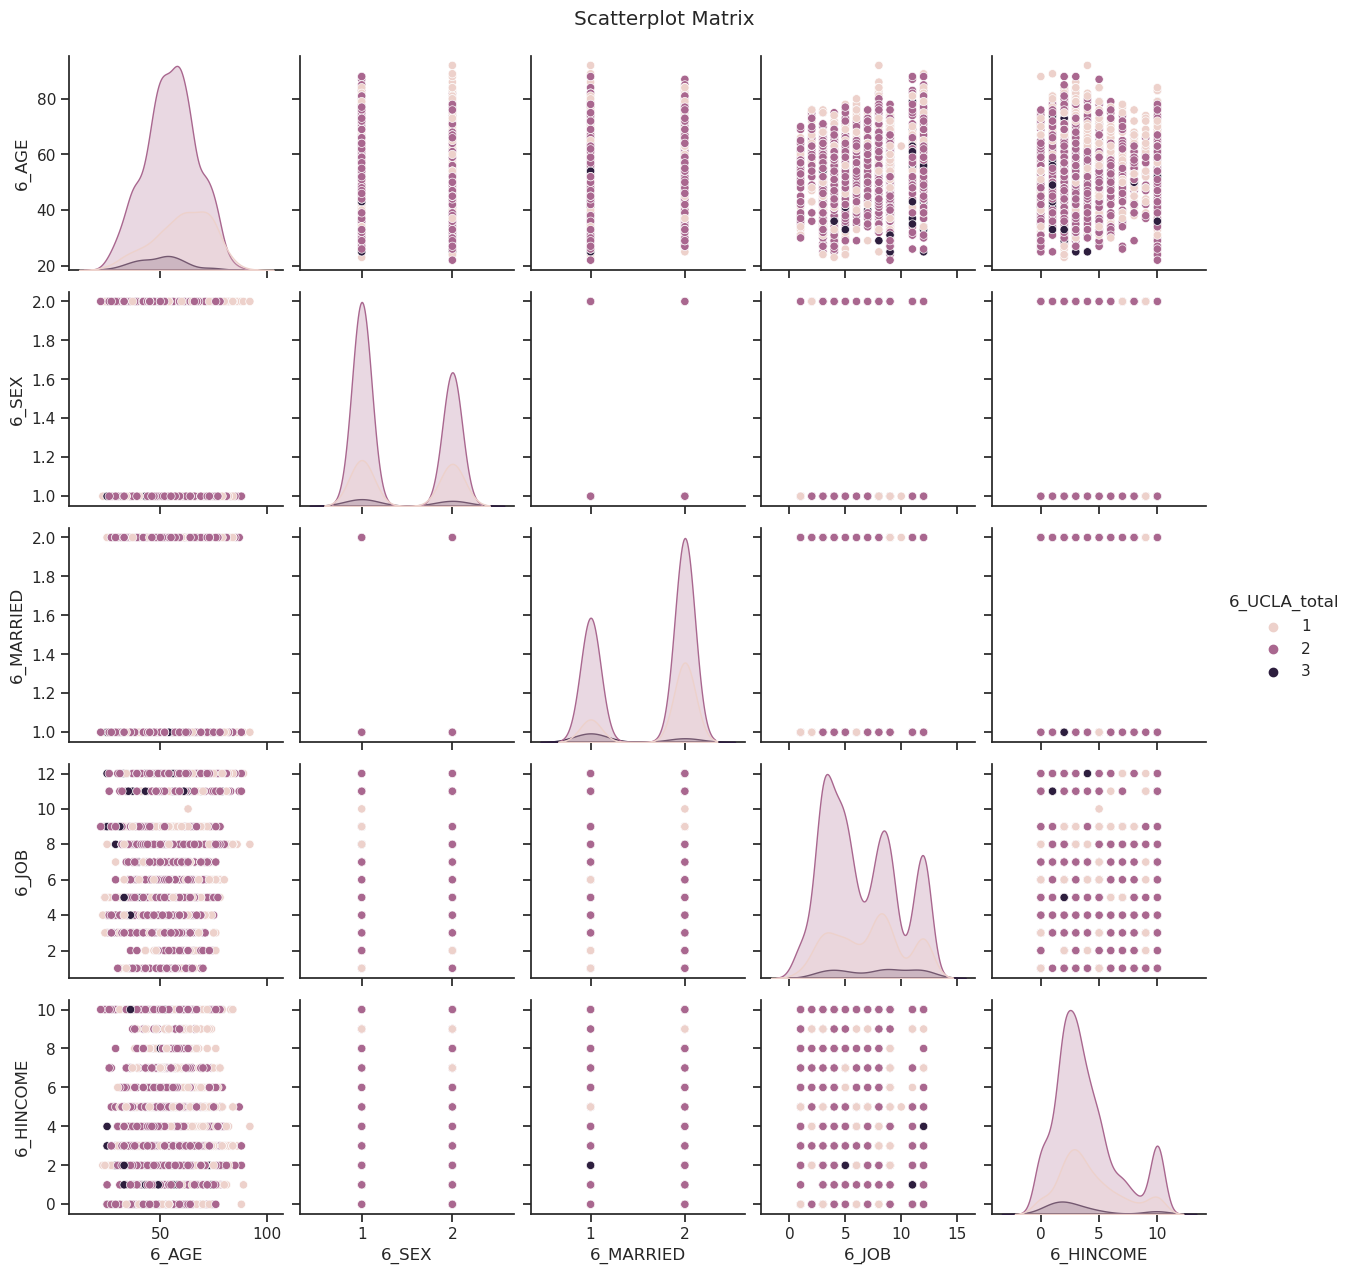

In [34]:
# https://seaborn.pydata.org/examples/scatterplot_matrix.html
# Scatterplot Matrix
sns.set_theme(style="ticks")
scatterplot_columns = ['6_AGE', '6_SEX', '6_MARRIED', '6_JOB', '6_HINCOME', '6_UCLA_total']
sns.pairplot(dataset_cleaned[scatterplot_columns], hue="6_UCLA_total")
plt.suptitle("Scatterplot Matrix", y=1.02)
plt.show()

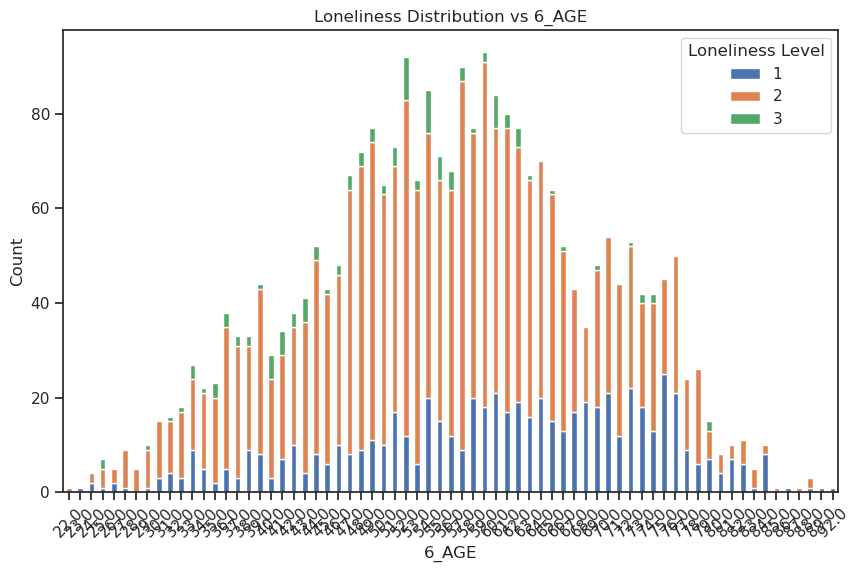

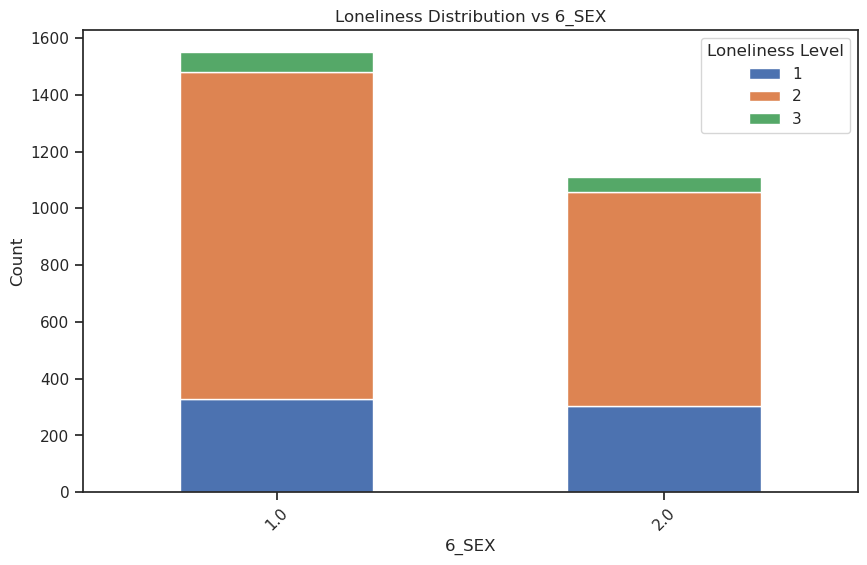

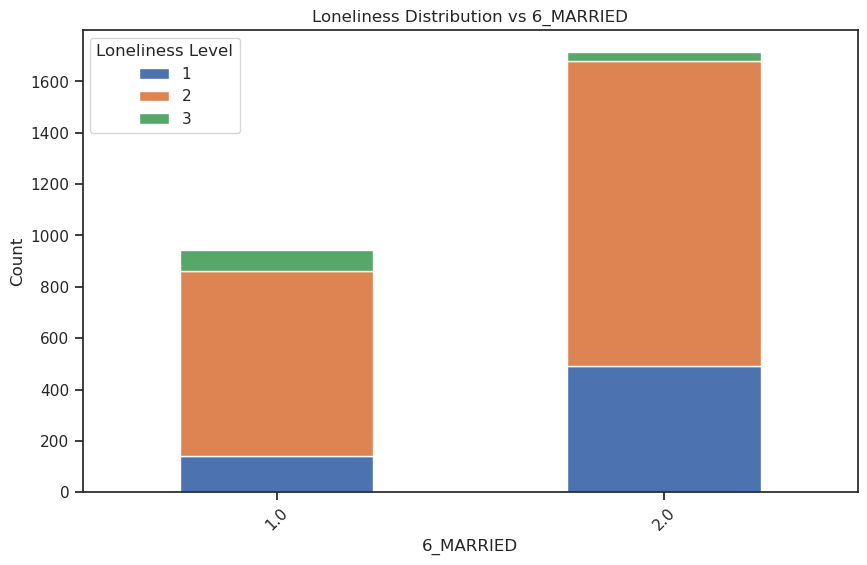

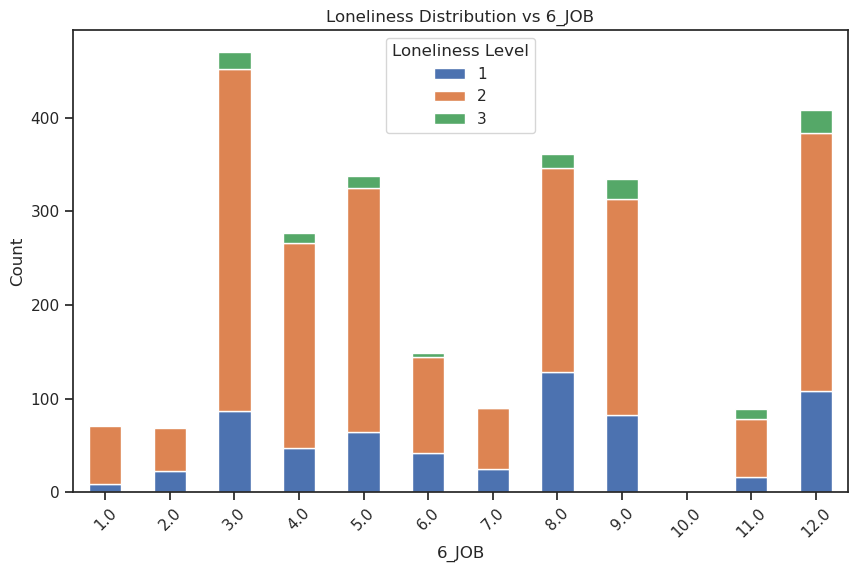

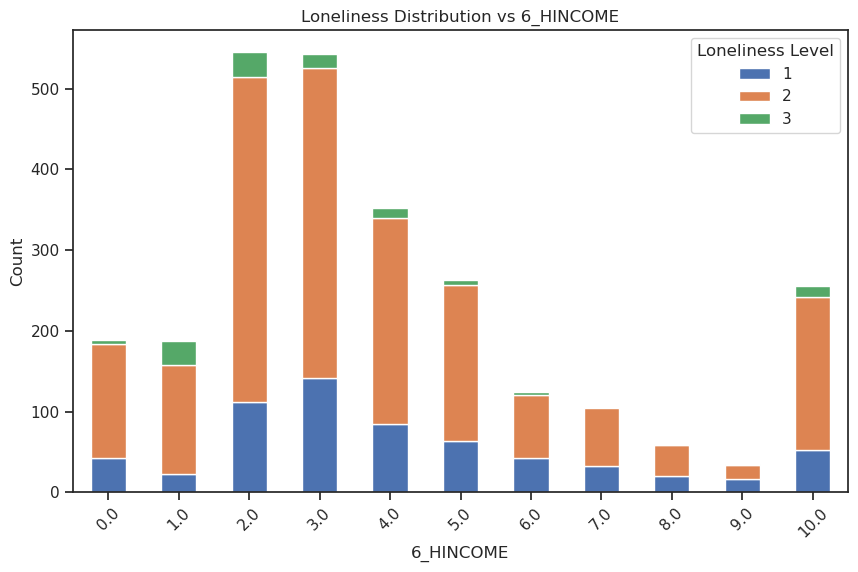

In [35]:
# https://www.geeksforgeeks.org/create-a-stacked-bar-plot-in-matplotlib/
demographic_vars = ['6_AGE', '6_SEX', '6_MARRIED', '6_JOB', '6_HINCOME']
loneliness_var = '6_UCLA_total'

for var in demographic_vars:
    stacked_data = dataset_cleaned.groupby([var, loneliness_var]).size().unstack(fill_value=0)

    stacked_data.plot(kind='bar', stacked=True, figsize=(10, 6), title=f'Loneliness Distribution vs {var}')
    plt.xlabel(var)
    plt.ylabel('Count')
    plt.legend(title='Loneliness Level')
    plt.xticks(rotation=45)
    plt.show()

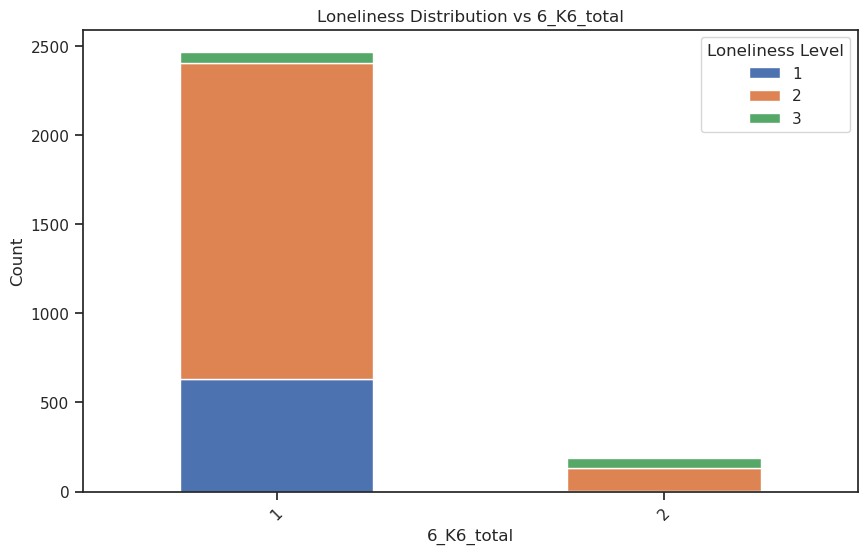

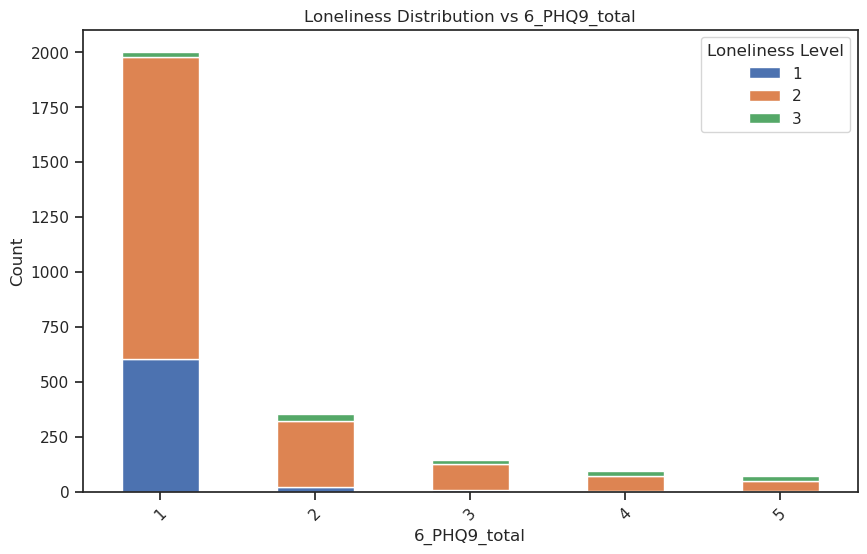

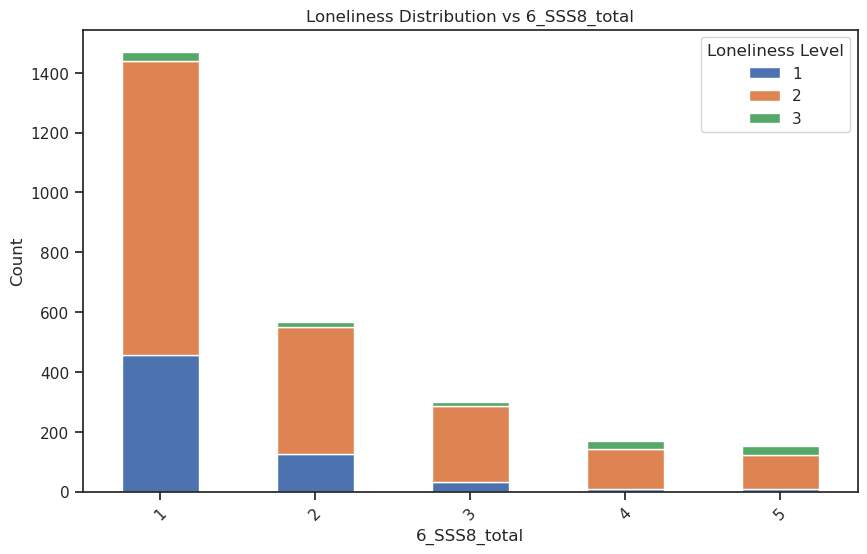

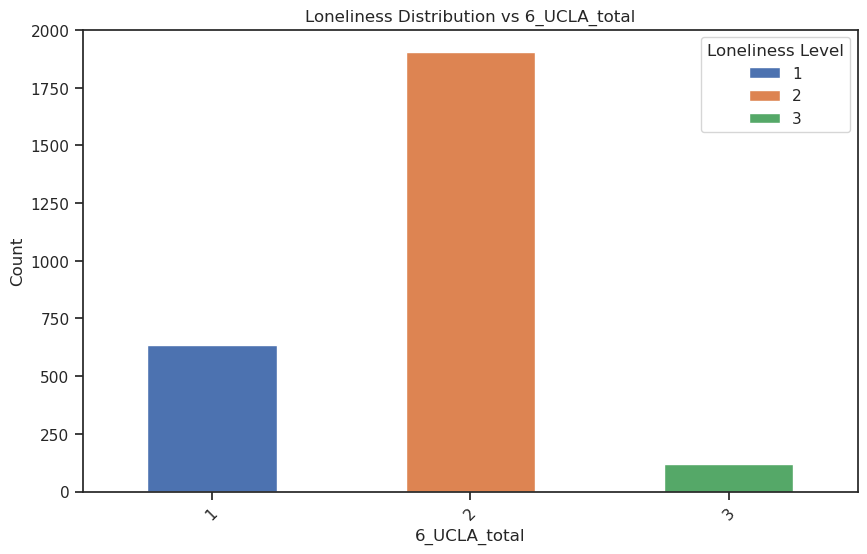

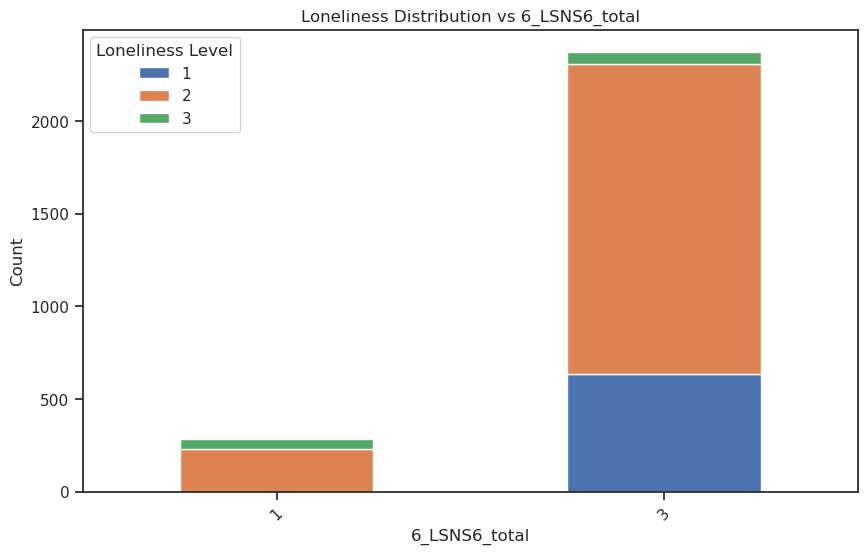

In [36]:
psych_vars = ['6_K6_total', '6_PHQ9_total', '6_SSS8_total', '6_UCLA_total', '6_LSNS6_total']
loneliness_var = '6_UCLA_total'

for var in psych_vars:
    stacked_data = dataset_cleaned.groupby([var, loneliness_var]).size().unstack(fill_value=0)

    stacked_data.plot(kind='bar', stacked=True, figsize=(10, 6), title=f'Loneliness Distribution vs {var}')
    plt.xlabel(var)
    plt.ylabel('Count')
    plt.legend(title='Loneliness Level')
    plt.xticks(rotation=45)
    plt.show()

In [37]:
# One-Hot Encoding for categorical variables

categorical_columns = [
    '6_SEX',
    '6_MARRIED',
    '6_JOB', ]
dataset_encoded = pd.get_dummies(dataset_cleaned, columns=categorical_columns, drop_first=True)
dataset_encoded.head()

,6_AGE,6_HINCOME,6_Exercise,6_HealthyDiet,6_HealthySleep,6_Interaction_offline,6_Interaction_online,6_DeteriorationEconomy,6_DeteriorationInteract,6_Frustration,...,6_JOB_3.0,6_JOB_4.0,6_JOB_5.0,6_JOB_6.0,6_JOB_7.0,6_JOB_8.0,6_JOB_9.0,6_JOB_10.0,6_JOB_11.0,6_JOB_12.0
4,57.0,4.0,5.0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,...,False,True,False,False,False,False,False,False,False,False
8,70.0,7.0,1.0,6.0,7.0,4.0,5.0,1.0,1.0,1.0,...,False,False,False,False,False,True,False,False,False,False
11,52.0,3.0,2.0,3.0,5.0,1.0,1.0,4.0,1.0,1.0,...,True,False,False,False,False,False,False,False,False,False
15,66.0,4.0,6.0,5.0,5.0,5.0,1.0,1.0,1.0,1.0,...,True,False,False,False,False,False,False,False,False,False
19,63.0,7.0,1.0,2.0,5.0,5.0,3.0,4.0,4.0,4.0,...,False,False,False,False,False,False,False,False,False,False
